In [30]:
import pandas as pd
from modules.predictor.data.utils import data_preprocessing

# df_experts1 = pd.read_csv('../../../data/raw/data_experts1.csv')
df_experts1 = data_preprocessing('../../../data/raw/data_experts1.csv', 'expert')
df_experts1

[22:41:31] Explicit valence for atom # 5 C, 5, is greater than permitted


,smiles,capacity_max
0,C#Cc1ccc(C#N)cc1,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,269.0
3,Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1,196.0
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4cccc...,228.0
5,N#C/C=C/C#N,404.0
6,N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1,383.0
7,N#Cc1c(F)c(F)c(C#N)c(F)c1F,379.0
8,N#Cc1c2ccccc2c(C#N)c2ccccc12,589.0
9,N#Cc1cc(C#N)c2ccc3c(C#N)cc(C#N)c4ccc1c2c43,500.0


Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


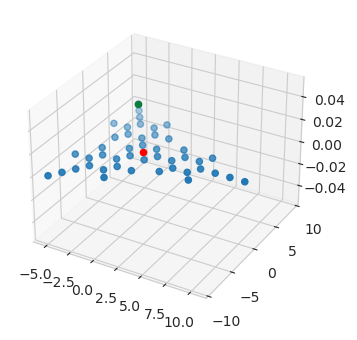

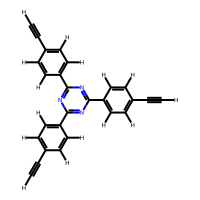

Pore size estimated: 4.0107045659157645, pore size true: nan
--------------------------------------------------------
Point group: C1
Symmetry description: no symmetry, chiral


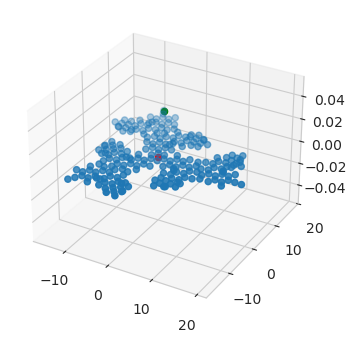

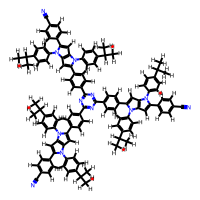

Pore size estimated: 7.508467268469016, pore size true: 3.6
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


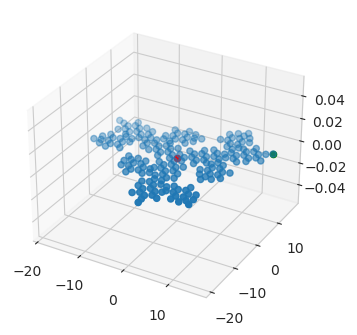

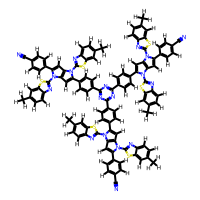

Pore size estimated: 7.492960724878604, pore size true: 3.6
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


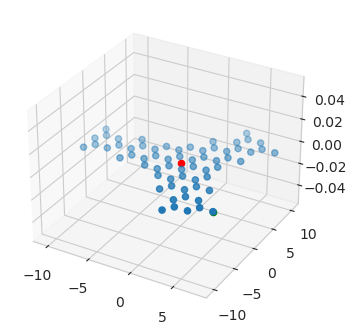

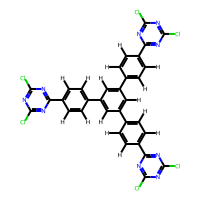

Pore size estimated: 4.131657418041952, pore size true: 3.2
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


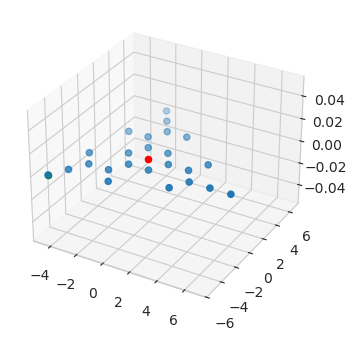

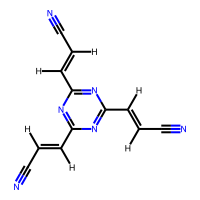

Pore size estimated: 2.6256224662019982, pore size true: 1.0
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


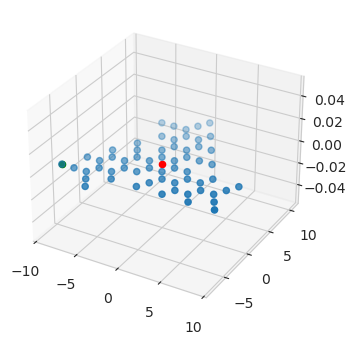

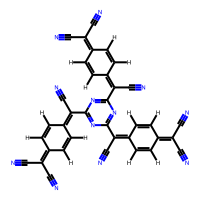

Pore size estimated: 3.969568047036904, pore size true: 0.9
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


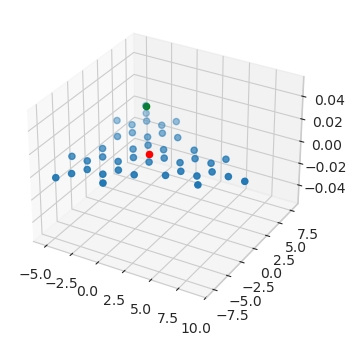

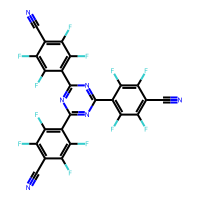

Pore size estimated: 3.4377467707849405, pore size true: 1.3
--------------------------------------------------------
Point group: C1
Symmetry description: no symmetry, chiral


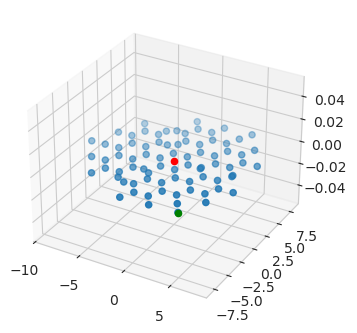

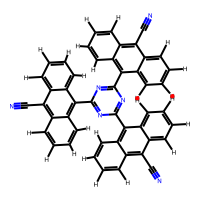

Pore size estimated: 3.438069096664891, pore size true: 1.3
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


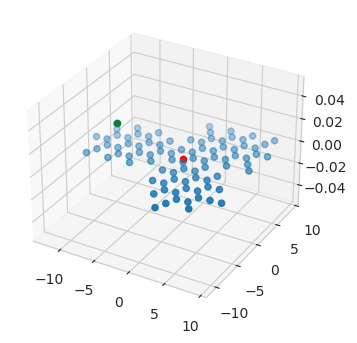

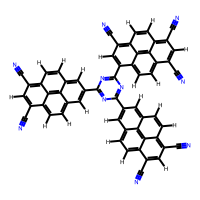

Pore size estimated: 4.776003051423045, pore size true: 1.1
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


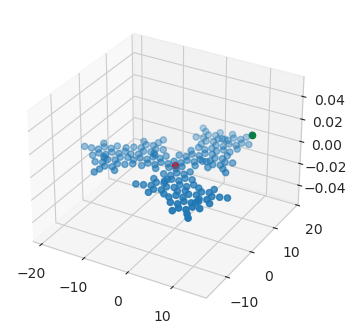

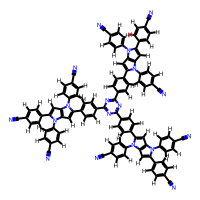

Pore size estimated: 7.493814717994093, pore size true: 3.6
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


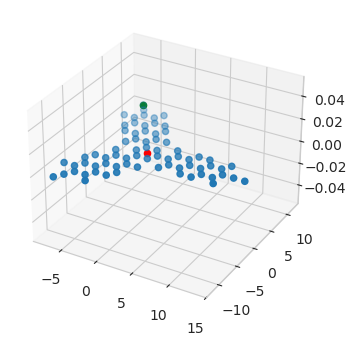

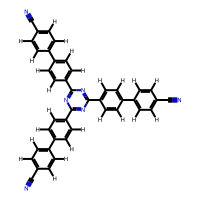

Pore size estimated: 5.156620156177412, pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


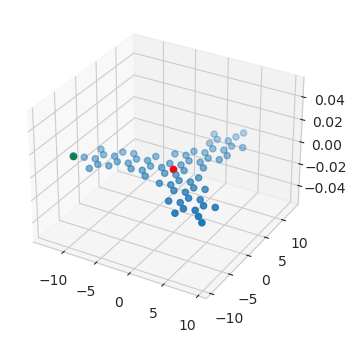

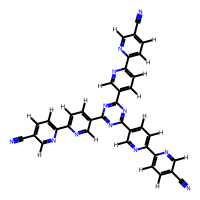

Pore size estimated: 5.1826855042806415, pore size true: 2.0
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


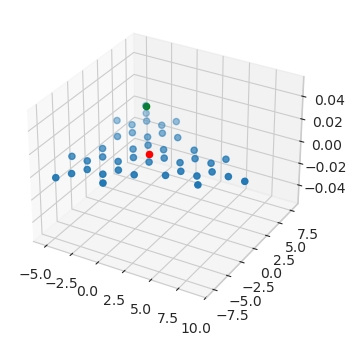

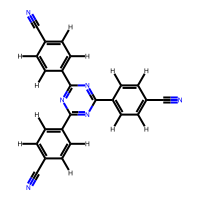

Pore size estimated: 3.4377467707849405, pore size true: 1.29
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


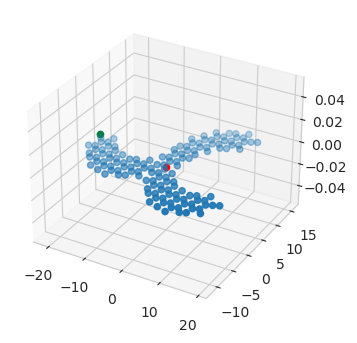

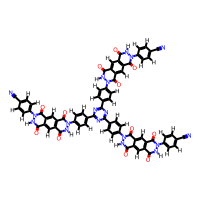

Pore size estimated: 8.261740738072238, pore size true: 3.8
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


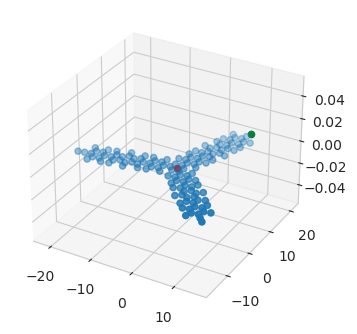

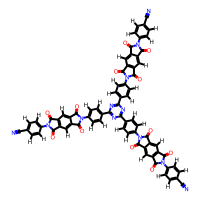

Pore size estimated: 8.485352736637827, pore size true: 3.9
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


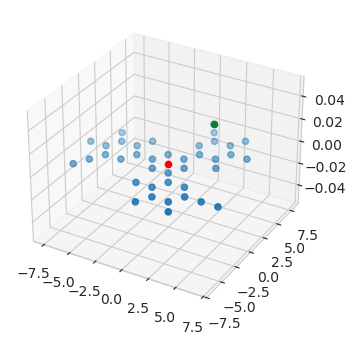

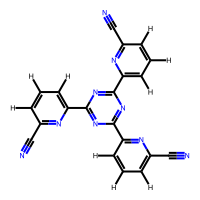

Pore size estimated: 2.9771760352776786, pore size true: 0.6
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


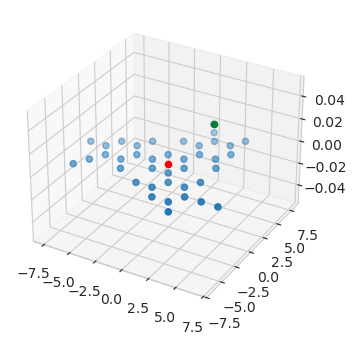

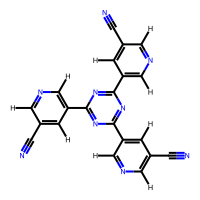

Pore size estimated: 2.9771760352776786, pore size true: 0.6
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


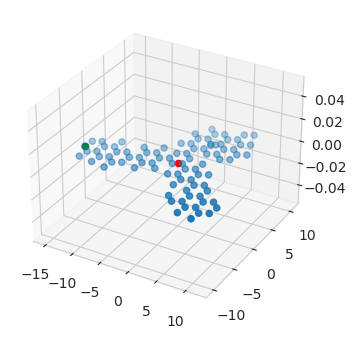

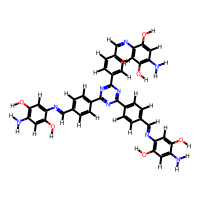

Pore size estimated: 5.898612220233752, pore size true: 3.4
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


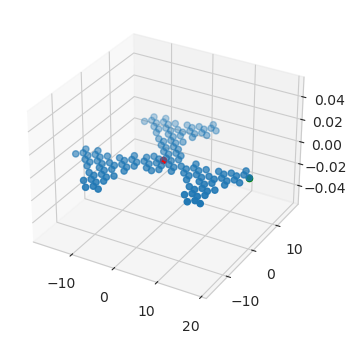

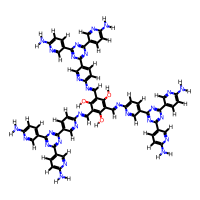

Pore size estimated: 7.135213301434717, pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


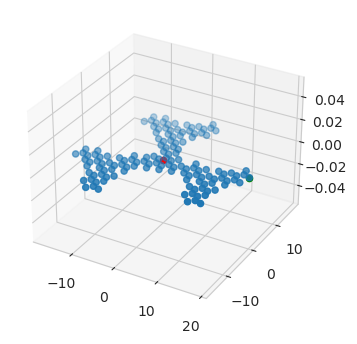

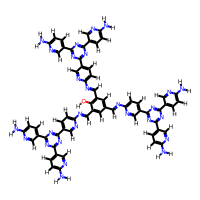

Pore size estimated: 7.14156768446197, pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


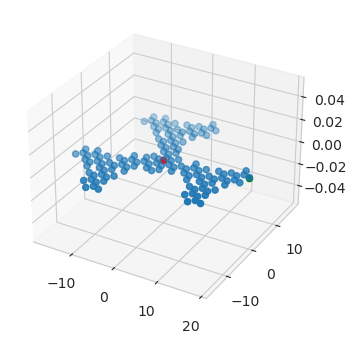

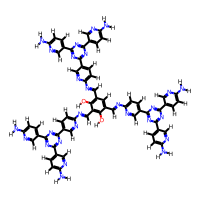

Pore size estimated: 7.142673944221488, pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


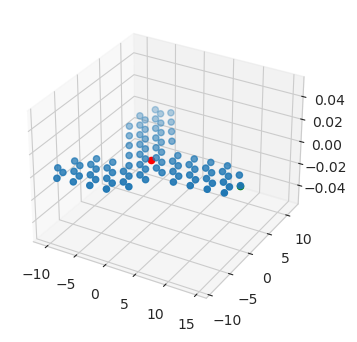

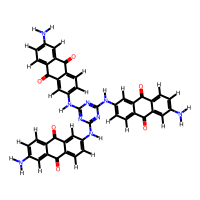

Pore size estimated: 5.645999625929663, pore size true: 2.9
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


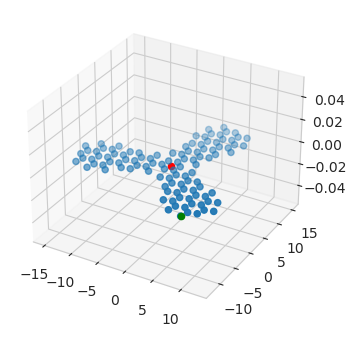

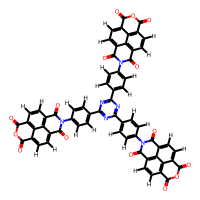

Pore size estimated: 5.814886543897335, pore size true: 4.2
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


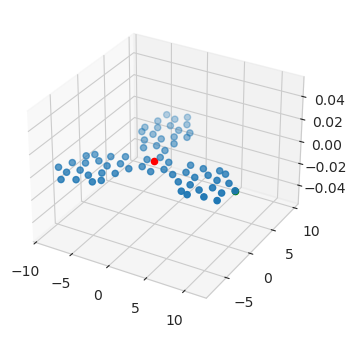

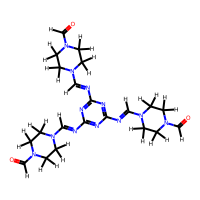

Pore size estimated: 4.353349297054105, pore size true: 2.3
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


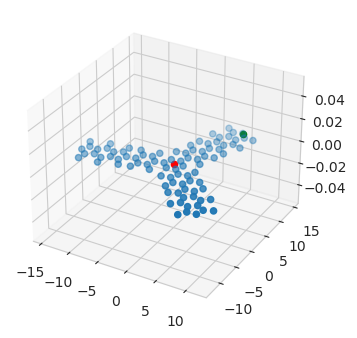

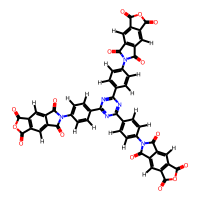

Pore size estimated: 5.62056376098371, pore size true: 4.2
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


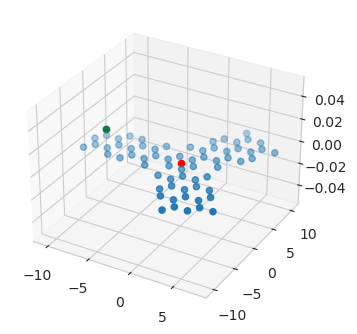

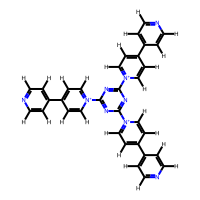

Pore size estimated: 4.131657418041952, pore size true: 2.4
--------------------------------------------------------


In [27]:
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize import view
from pymatgen.vis.structure_chemview import quick_view
from modules.core.features.symmetries import translate_point_group_to_symmetry_description
from modules.core.features.utils import get_pymatgen_molecule_from_smiles
from pymatgen.symmetry.analyzer import PointGroupAnalyzer
import pandas as pd
import numpy as np

from pymatgen.vis.structure_vtk import StructureVis

from rdkit import Chem
from rdkit.Chem import AllChem, Mol, MolToXYZFile, rdDepictor, rdDistGeom
import matplotlib.pyplot as plt

from modules.core.features.preprocessing import canon_smiles

df = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')
df['canon_smiles'] = [canon_smiles(s) for s in df['smiles'].tolist()]
df = df[['canon_smiles', 'wielkosc_pora teoretyczna']].groupby('canon_smiles').aggregate('mean').reset_index()
pore_sizes = df['wielkosc_pora teoretyczna'].tolist()
smiles = df['canon_smiles'].tolist()

# smiles = df.drop_duplicates(subset=['smiles'])['smiles'].tolist()
# smiles = [canon_smiles(s) for s in smiles]
#
for s, p in zip(smiles, pore_sizes):
    TRANSLATION_TABLE_PATH = "../../../data/symmetries/symmetry_translation.csv"

    molecule = get_pymatgen_molecule_from_smiles(s, save_file=True)
    pga = PointGroupAnalyzer(molecule)
    symmetry_operations = pga.get_symmetry_operations()
    rotational_symmetry = pga.get_rotational_symmetry_number()
    point_group = pga.get_pointgroup()
    equivalent_atoms = pga.get_equivalent_atoms()

    # print(f"Symmetry operations: {symmetry_operations}")
    # print(f"Rotational symmetry number: {rotational_symmetry}")
    print(f"Point group: {point_group}")
    #print(pga.inversion_op)
    #print(f"Equivalent atoms: {equivalent_atoms}")

    symmetry_description = translate_point_group_to_symmetry_description(str(point_group), TRANSLATION_TABLE_PATH)
    print(f"Symmetry description: {symmetry_description}")
    #structure = molecule.get_boxed_structure(23, 23, 23)

    #view(AseAtomsAdaptor().get_atoms(structure))
    # coordinates = []
    # species = []
    #
    # for s in structure:
    #         coordinates.append(s.coords) #cartesian coordinates
    #         species.append(s.specie)
    #
    # print(coordinates)
    # print(species)
    molecule = Chem.MolFromSmiles(s, sanitize=True)
    molecule = Chem.AddHs(molecule)
    rdDepictor.Compute2DCoords(molecule, sampleSeed=42)

    nitrogen_indices = [
            bond.GetEndAtomIdx() if bond.GetBeginAtom().GetSymbol() == "C" and bond.GetEndAtom().GetSymbol() == "N" else bond.GetBeginAtomIdx()
            for bond in molecule.GetBonds()
            if bond.GetBondType() == Chem.BondType.TRIPLE and {"C", "N"} == {bond.GetBeginAtom().GetSymbol(), bond.GetEndAtom().GetSymbol()}
        ]
    if len(nitrogen_indices) == 0:
        nitrogen_indices = list(range(0, molecule.GetNumAtoms()))

    conf = molecule.GetConformer(0)
    coords = conf.GetPositions()

    max_distance = 0
    atom_pos = None

    for j in nitrogen_indices: #range(0, molecule.GetNumAtoms()):
        pos_j = np.array(conf.GetAtomPosition(j))

        # Calculate the distance between the two points
        distance = np.linalg.norm(np.array([0, 0, 0]) - pos_j)

        if distance > max_distance:
            max_distance = distance
            atom_pos = pos_j

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2])
    ax.scatter(0, 0, 0, c='red')
    ax.scatter(atom_pos[0], atom_pos[1], atom_pos[2], c='green')
    plt.show()
    display(Chem.Draw.MolsToImage([molecule]))

    perimeter = max_distance * 2 * 6

    pore_diameter = perimeter / np.pi

    pore_diameter_nm = pore_diameter / 10  # Convert to nanometers
    print(f'Pore size estimated: {pore_diameter_nm}, pore size true: {p}')

    print('--------------------------------------------------------')

In [4]:
import pandas as pd
import os
maccs_path = '../../../data/fingerprints_maccs/'
data_paths = ['data_experts1', 'data_zhu', 'data_saad', 'data_experts2', 'data_experts3']
dfs = []
for d in data_paths:
    df = pd.read_csv(os.path.join(maccs_path, f'{d}.csv'))
    df.columns = df.columns.str.replace(r"[\[\]>]", "", regex=True)
    df = df.sort_values(by="smiles").reset_index(drop=True)
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True).sort_values(by="smiles").reset_index(drop=True)
df_all = df_all.loc[:, ~df_all.eq(df_all.iloc[0]).all()]
df_all.to_csv('maccs_merged.csv')


In [5]:
df_all

,maccsfingerprint6,maccsfingerprint9,maccsfingerprint16,maccsfingerprint17,maccsfingerprint23,maccsfingerprint24,maccsfingerprint27,maccsfingerprint31,maccsfingerprint32,maccsfingerprint33,...,maccsfingerprint158,maccsfingerprint159,maccsfingerprint160,maccsfingerprint161,maccsfingerprint162,maccsfingerprint163,maccsfingerprint164,maccsfingerprint165,capacity_max,smiles
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,39.45,Brc1ccc(C(c2ccc(Br)cc2)C(c2ccc(Br)cc2)c2ccc(-c...
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,51.00,Brc1ccc(C(c2ccc(Br)cc2)C(c2ccc(Br)cc2)c2ccc(-c...
2,0,0,0,0,0,1,0,0,0,0,...,0,0,1,1,1,0,1,0,407.00,Brc1ccc(Nc2nc(Nc3ccc(Br)s3)nc(Nc3ccc(Br)s3)n2)s1
3,0,0,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,1,0,628.00,C#Cc1ccc(C#N)cc1
4,0,0,1,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,31.37,C#Cc1ccc(N2COc3cc4c(cc3C2)OCN(c2ccc(C#Cc3ccc5c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,0,0,0,0,0,1,0,0,0,0,...,0,0,1,1,1,0,1,0,196.00,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...
91,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,1,0,300.00,c1ccc2c(c1)c1ccccc1n2-c1ccc(-c2ccc(-n3c4ccccc4...
92,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,1,0,380.00,c1ccc2c(c1)c1ccccc1n2-c1ccc(N(c2ccc(-n3c4ccccc...
93,0,0,0,0,0,1,0,0,0,0,...,0,0,1,1,1,0,1,0,550.00,c1ccc2c(c1)c1ccccc1n2-c1nc(-n2c3ccccc3c3ccccc3...


In [37]:
from modules.core.features.preprocessing import preprocess_target, canon_smiles

df_corrected = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')
column_names_mapping = {
        "zwiazek": "substance",
        "smiles": "smiles",
        "masa_molowa": "molecular_weight",
        "liczba_pierscieni": "number_of_rings",
        "srednia_liczba_N_w_pierscieniu": "average_number_of_N_in_ring",
        "liczba_substratu_w_porze": "number_of_substrates_in_pore",
        "energia Gibbsa": "Gibbs_energy",
        "odleglosc_miedzy_najdalszymi_grupami": "distance_between_furthest_groups",
        "kondensacja": "condensation",
        "piroliza": "pyrolysis",
        "temperatura": "temperature",
        "N_perc_triaz": "N_perc_triaz",
        "wielkosc_pora teoretyczna": "PS",  # Pore Size
        "BET": "SSA",  # BET surface area
        "objetosc": "PV",  # Pore Volume
        "objetosc_mikroporow": "micropore_volume",
        "pojemnosc_3_H2SO4_CV": "capacity_H2SO4_CV",
        "pojemnosc_3_H2SO4_GCD": "capacity_H2SO4_GCD",
        "pojemnosc_3_NaOH_CV": "capacity_NaOH_CV",
        "pojemnosc_3_NaOH_GCD": "capacity_NaOH_GCD",
        "SSSS": "SSSSS",
    }

df_experts = df_corrected.rename(columns=column_names_mapping)
df_experts[["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]] = df_experts[
    ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
].replace("~", "", regex=True)
df_experts[["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]] = df_experts[
    ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
].astype(float)

# Calculate mean capacity
df_experts["capacity_H2SO4_mean"] = df_experts.loc[:, ["capacity_H2SO4_CV", "capacity_H2SO4_GCD"]].mean(axis=1)
df_experts["capacity_NaOH_mean"] = df_experts.loc[:, ["capacity_NaOH_CV", "capacity_NaOH_GCD"]].mean(axis=1)
df_experts["capacity_mean"] = df_experts.loc[:, ["capacity_H2SO4_mean", "capacity_NaOH_mean"]].mean(axis=1)

targets = ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
df_experts["capacity_max"] = preprocess_target(df_experts, targets=targets)

df_experts = df_experts.loc[~df_experts["capacity_max"].isna()].reset_index(drop=True)

df_experts["smiles"] = df_experts["smiles"].apply(canon_smiles)
df_experts['smiles_old'] = df_experts['smiles_old'].apply(canon_smiles)
df_experts.dropna(subset=["smiles", 'smiles_old'], inplace=True)
df_experts = df_experts.rename(columns={'smiles': 'smiles_new', 'smiles_old': 'smiles'})

df_corrected = df_experts[['smiles_new', 'smiles', 'capacity_max']]
df_corrected = df_corrected.groupby(["smiles", "smiles_new"]).max("capacity_max").reset_index()
df_corrected

[22:51:07] Explicit valence for atom # 5 C, 5, is greater than permitted


,smiles,smiles_new,capacity_max
0,C#Cc1ccc(C#N)cc1,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0
3,Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4cccc...,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0
5,N#C/C=C/C#N,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0
6,N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0
7,N#Cc1c(F)c(F)c(C#N)c(F)c1F,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0
8,N#Cc1c2ccccc2c(C#N)c2ccccc12,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0
9,N#Cc1cc(C#N)c2ccc3c(C#N)cc(C#N)c4ccc1c2c43,N#Cc1cc(C#N)c2ccc3cc(-c4nc(-c5cc6ccc7c(C#N)cc(...,500.0


In [39]:
df_merged = df_experts1.merge(df_corrected, left_on='smiles', right_on='smiles')
df_merged

,smiles,capacity_max_x,smiles_new,capacity_max_y
0,C#Cc1ccc(C#N)cc1,628.0,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,269.0,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0
3,Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1,196.0,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4cccc...,228.0,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0
5,N#C/C=C/C#N,404.0,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0
6,N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1,383.0,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0
7,N#Cc1c(F)c(F)c(C#N)c(F)c1F,379.0,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0
8,N#Cc1c2ccccc2c(C#N)c2ccccc12,589.0,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0
9,N#Cc1cc(C#N)c2ccc3c(C#N)cc(C#N)c4ccc1c2c43,500.0,N#Cc1cc(C#N)c2ccc3cc(-c4nc(-c5cc6ccc7c(C#N)cc(...,500.0


In [41]:
smiles1 = df_experts1['smiles'].tolist()
smiles2 = df_merged['smiles'].tolist()

print(smiles1)

['C#Cc1ccc(C#N)cc1', 'CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(C#N)cc2)n3-c2ccc(C(C)C)cc2)cc1', 'Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C#N)cc3)n4-c3nc4ccc(C)cc4s3)sc2c1', 'Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1', 'Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4ccccc4)c3)cc2)n1', 'N#C/C=C/C#N', 'N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1', 'N#Cc1c(F)c(F)c(C#N)c(F)c1F', 'N#Cc1c2ccccc2c(C#N)c2ccccc12', 'N#Cc1cc(C#N)c2ccc3c(C#N)cc(C#N)c4ccc1c2c43', 'N#Cc1ccc(-c2cc3c(cc(-c4ccc(C#N)cc4)n3-c3ccc(C#N)cc3)n2-c2ccc(C#N)cc2)cc1', 'N#Cc1ccc(-c2ccc(C#N)cc2)cc1', 'N#Cc1ccc(-c2ccc(C#N)cn2)nc1', 'N#Cc1ccc(-n2[nH]c(=O)c3cc4c(=O)[nH]n(-c5ccc(C#N)cc5)c(=O)c4cc3c2=O)cc1', 'N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(C#N)cc5)c(=O)c4cc3c2=O)cc1', 'N#Cc1ccc(C#N)cc1', 'N#Cc1cccc(C#N)n1', 'Nc1cc(O)c(N=Cc2ccc(-c3nc(-c4ccc(C=O)cc4)nc(-c4ccc(C=O)cc4)n3)cc2)cc1O', 'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(-n4c(=O)c5cc6c(=O)oc(=O)c6cc5c4=O)cc3)n2)cc1', 'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(N4C(=O)c5ccc6c7c(ccc(c57)C4=O)C(=O)OC6=O)cc

In [43]:
df_merged = df_merged[['smiles_new', 'capacity_max_y']]
df_merged = df_merged.rename(columns={'smiles_new': 'smiles', 'capacity_max_y': 'capacity_max'})
df_merged

,smiles,capacity_max
0,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0
3,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0
5,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0
6,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0
8,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0
9,N#Cc1cc(C#N)c2ccc3cc(-c4nc(-c5cc6ccc7c(C#N)cc(...,500.0


In [44]:
df_merged.to_csv('../../../data/raw/data_experts1_corrected_matched.csv')

In [45]:
df_f = pd.read_csv('../../../data/processed_selected_custom_features/data_experts1_corrected_all.csv')
df_merged = df_merged.merge(df_f, left_on='smiles', right_on='smiles')
df_merged

,smiles,capacity_max_x,capacity_max_y,flatness,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0,628.0,0.678421,3.081823,C1,90.000000,10.000000,0.000000,4.81650,30,33,4,3,3,3,0,38.67,381.126597
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,255.0,NaN,5.922206,C1,90.476190,9.523810,0.000000,29.43384,126,144,19,12,21,12,0,139.62,1632.788091
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,269.0,NaN,5.458141,C1,81.818182,13.636364,0.000000,28.20216,132,156,25,24,15,18,0,216.96,1806.404210
3,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,196.0,1.054200,3.505856,C1,78.571429,21.428571,0.000000,3.88770,42,48,7,9,6,9,0,88.98,546.213821
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,228.0,0.749688,3.694051,D2,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
5,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,404.0,0.383308,2.188308,Cs,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
6,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,383.0,1.497775,3.329008,C1,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,379.0,1.463338,2.706561,C1,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
8,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,589.0,2.206805,2.712779,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
9,N#Cc1cc(C#N)c2ccc3cc(-c4nc(-c5cc6ccc7c(C#N)cc(...,500.0,500.0,1.692511,4.106737,C1,85.294118,14.705882,0.000000,12.66656,68,80,13,10,3,10,0,205.20,856.187241


In [46]:
df_merged.dropna()

,smiles,capacity_max_x,capacity_max_y,flatness,PS,symmetry,%C,%N,%O,MolLogP,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt
0,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0,628.0,0.678421,3.081823,C1,90.000000,10.000000,0.000000,4.81650,30,33,4,3,3,3,0,38.67,381.126597
3,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,196.0,1.054200,3.505856,C1,78.571429,21.428571,0.000000,3.88770,42,48,7,9,6,9,0,88.98,546.213821
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,228.0,0.749688,3.694051,D2,68.750000,18.750000,0.000000,10.16400,48,54,7,15,6,9,0,116.01,746.958158
5,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,404.0,0.383308,2.188308,Cs,66.666667,33.333333,0.000000,1.48194,18,18,1,6,3,6,0,110.04,234.065394
6,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,383.0,1.497775,3.329008,C1,75.000000,25.000000,0.000000,-0.36708,48,51,4,12,3,12,0,252.78,612.130788
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,379.0,1.463338,2.706561,C1,57.142857,14.285714,0.000000,6.15684,42,45,4,18,3,6,0,110.04,599.999283
8,N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc3...,589.0,589.0,2.206805,2.712779,C1,88.888889,11.111111,0.000000,11.40684,54,63,10,6,3,6,0,110.04,684.206245
9,N#Cc1cc(C#N)c2ccc3cc(-c4nc(-c5cc6ccc7c(C#N)cc(...,500.0,500.0,1.692511,4.106737,C1,85.294118,14.705882,0.000000,12.66656,68,80,13,10,3,10,0,205.20,856.187241
11,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc...,280.0,280.0,1.052006,4.157964,C1,87.500000,12.500000,0.000000,9.48864,48,54,7,6,6,6,0,110.04,612.206245
12,N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cn5)nc...,393.0,393.0,1.005745,4.094862,C1,75.000000,25.000000,0.000000,5.85864,48,54,7,12,6,12,0,187.38,618.177739


In [15]:
from modules.core.features.preprocessing import canon_smiles
import os

import pandas as pd

from modules.predictor.data.utils import data_preprocessing

# Load data
main_dir = '../../../data'
data_types = {
    'expert': 'data_experts1.csv',
    'expert2': 'data_experts2.csv',
    'expert3': 'data_experts3.csv',
    'zhu': 'data_zhu.csv',
    'saad': 'data_saad.csv',
}
min_smiles = {}
for dtype in data_types:
    print(dtype)
    df = pd.read_csv(os.path.join(main_dir, 'raw', data_types[dtype]))
    df.columns = [x.lower() for x in df.columns]
    df['smiles'] = df['smiles'].apply(canon_smiles)
    df.dropna(subset=['smiles'], inplace=True)
    df.drop_duplicates(subset=['smiles'], inplace=True)
    min_smiles[dtype] = df['smiles'].tolist()

expert
expert2
expert3
zhu
saad


[14:48:31] Explicit valence for atom # 5 C, 5, is greater than permitted
[14:48:31] SMILES Parse Error: syntax error while parsing: CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].
[14:48:31] SMILES Parse Error: Failed parsing SMILES 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].' for input: 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].'
[14:48:31] SMILES Parse Error: syntax error while parsing: CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].
[14:48:31] SMILES Parse Error: Failed parsing SMILES 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].' for input: 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].'
[14:48:31] SMILES Parse Error: syntax error while parsing: CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].
[14:48:31] SMILES Parse Error: Failed parsing SMILES 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].' for input: 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].'
[14:48:31] Explicit valence for atom # 11 O, 3, is greater than permitted
[14:48:31] Explicit valence for atom # 19 O, 3, is greater than permitted
[14:48:31] Explicit valence for atom # 19 O, 3, is greater than permitted


In [16]:
min_smiles

{'expert': ['CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(C#N)cc2)n3-c2ccc(C(C)C)cc2)cc1',
  'N#Cc1ccc(C#N)cc1',
  'N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1',
  'Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C#N)cc3)n4-c3nc4ccc(C)cc4s3)sc2c1',
  'N#Cc1ccc(-c2cc3c(cc(-c4ccc(C#N)cc4)n3-c3ccc(C#N)cc3)n2-c2ccc(C#N)cc2)cc1',
  'Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4ccccc4)c3)cc2)n1',
  'N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(C#N)cc5)c(=O)c4cc3c2=O)cc1',
  'N#Cc1cncc(C#N)c1',
  'Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Cl)nc(Cl)n3)cc1C2=O',
  'Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1',
  'N#C/C=C/C#N',
  'Nc1cc(O)c(N=Cc2ccc(-c3nc(-c4ccc(C=O)cc4)nc(-c4ccc(C=O)cc4)n3)cc2)cc1O',
  'N#Cc1ccc(-n2[nH]c(=O)c3cc4c(=O)[nH]n(-c5ccc(C#N)cc5)c(=O)c4cc3c2=O)cc1',
  'N#Cc1ccc(-c2ccc(C#N)cc2)cc1',
  'N#Cc1ccc(-c2ccc(C#N)cn2)nc1',
  'N#Cc1cccc(C#N)n1',
  'N#Cc1c(F)c(F)c(C#N)c(F)c1F',
  'Nc1nc(N)nc(N=CN2CCN(C=O)CC2)n1',
  'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(-n4c(=O)c5cc6c(=O)oc(=O)c6cc5c4=O)cc3)n2)cc1',
  'Nc1ccc(-c2nc(-c3ccc(N)

In [17]:
for dtype, dlist in min_smiles.items():
    print(dtype, len(dlist))

expert 26
expert2 22
expert3 29
zhu 24
saad 2


In [18]:
for subdir in [s for s in os.listdir(main_dir) if s not in ['sampling', 'raw', 'symmetries', 'processed_all_custom_features']]:
    print(subdir)
    for dtype, dfile in data_types.items():
        df = pd.read_csv(os.path.join(main_dir, subdir, dfile))
        df.columns = [x.lower() for x in df.columns]
        df['smiles'] = df['smiles'].apply(canon_smiles)
        df.dropna(subset=['smiles'], inplace=True)
        df.drop_duplicates(subset=['smiles'], inplace=True)
        smiles_file = df['smiles'].tolist()
        smiles_now = min_smiles[dtype]
        print(len(smiles_now), len(smiles_file), len([x for x in smiles_now if x in smiles_file]))
        new_smiles = [x for x in smiles_now if x in smiles_file]
        min_smiles[dtype] = new_smiles

fingerprints_layered
26 24 24
22 22 22
29 29 29
24 21 20
2 1 1
fingerprints_topological
24 24 24
22 22 22
29 29 29
20 21 20
1 1 1
fingerprints_maccs
24 24 24
22 22 22
29 29 29
20 21 20
1 1 1
fingerprints_layered_512
24 24 24
22 22 22
29 29 29
20 20 19
1 1 1
aggregated_dft_features
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
custom_features_mlxtend
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
fingerprints_layered_256
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
additive_groups
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
fingerprints_topological_512
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
processed_selected_custom_features
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
fingerprints_functional_groups
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
fingerprints_ecfp
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
fingerprints_estate
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
aggregated_selected_dft_features
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
fingerprints_topological_256
24 24 24
22 22 22
29 29 29
19 21 19
1 

In [19]:
for dtype, dlist in min_smiles.items():
    print(dtype, len(dlist))

expert 24
expert2 22
expert3 29
zhu 19
saad 1


In [26]:
for subdir in [s for s in os.listdir(main_dir) if s not in ['sampling', 'raw', 'symmetries', 'processed_all_custom_features']]:
    print(subdir)
    for dtype, dfile in data_types.items():
        df = pd.read_csv(os.path.join(main_dir, subdir, dfile))
        df.columns = [x.lower() for x in df.columns]
        df['smiles'] = df['smiles'].apply(canon_smiles)
        df.dropna(subset=['smiles'], inplace=True)
        df.drop_duplicates(subset=['smiles'], inplace=True)
        df = df[df['smiles'].isin(min_smiles[dtype])]
        print(dtype, subdir, len(df))
        df.to_csv(os.path.join(main_dir, subdir, dfile), index=False)

fingerprints_layered
expert fingerprints_layered 24
expert2 fingerprints_layered 22
expert3 fingerprints_layered 29
zhu fingerprints_layered 19
saad fingerprints_layered 1
fingerprints_topological
expert fingerprints_topological 24
expert2 fingerprints_topological 22
expert3 fingerprints_topological 29
zhu fingerprints_topological 19
saad fingerprints_topological 1
fingerprints_maccs
expert fingerprints_maccs 24
expert2 fingerprints_maccs 22
expert3 fingerprints_maccs 29
zhu fingerprints_maccs 19
saad fingerprints_maccs 1
fingerprints_layered_512
expert fingerprints_layered_512 24
expert2 fingerprints_layered_512 22
expert3 fingerprints_layered_512 29
zhu fingerprints_layered_512 19
saad fingerprints_layered_512 1
aggregated_dft_features
expert aggregated_dft_features 24
expert2 aggregated_dft_features 22
expert3 aggregated_dft_features 29
zhu aggregated_dft_features 19
saad aggregated_dft_features 1
custom_features_mlxtend
expert custom_features_mlxtend 24
expert2 custom_features_mlxt

In [33]:

paths = ['../../../data/processed_selected_custom_features/data_experts1.csv',
         '../../../data/fingerprints_layered/data_experts1.csv',
         ]
df = [pd.read_csv(data_path) for data_path in paths]
result = df[0]
for data in df[1:]:
    data = data.drop(columns=['capacity_max'])
    result = pd.merge(result, data, on='smiles', how='inner')
# df = pd.concat(df, axis=1).reset_index(drop=True)
result.columns = result.columns.str.replace(r"[\[\]>]", "", regex=True)
result =result.loc[:, ~result.columns.duplicated()].sort_values(by="smiles").reset_index(drop=True)
result
#print(df)

,smiles,capacity_max,flatness,ps,%c,%n,%o,mollogp,num_atoms,num_bonds,...,layeredfingerprint118,layeredfingerprint119,layeredfingerprint120,layeredfingerprint121,layeredfingerprint122,layeredfingerprint123,layeredfingerprint124,layeredfingerprint125,layeredfingerprint126,layeredfingerprint127
0,C#Cc1ccc(C#N)cc1,628.0,0.158494,1.527471,90.000000,10.000000,0.000000,1.53958,10,10,...,0,1,0,0,1,0,0,1,1,1
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,1.750266,3.422303,90.476190,9.523810,0.000000,9.74536,42,47,...,0,1,1,1,1,1,1,1,1,1
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,269.0,1.674914,3.444589,81.818182,13.636364,0.000000,9.33480,44,51,...,1,1,1,1,1,1,1,1,1,1
3,Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1,196.0,0.690551,2.203633,65.000000,25.000000,0.000000,2.51710,20,22,...,0,1,1,1,1,1,1,0,1,1
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4cccc...,228.0,0.732465,2.853515,84.375000,9.375000,0.000000,7.84640,32,36,...,0,1,1,1,1,1,1,0,1,1
5,N#C/C=C/C#N,404.0,0.028831,1.135324,66.666667,33.333333,0.000000,0.58976,6,5,...,0,0,0,0,1,0,1,0,0,0
6,N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1,383.0,0.341812,1.784802,75.000000,25.000000,0.000000,0.08232,16,16,...,1,1,0,1,1,0,1,1,1,1
7,N#Cc1c(F)c(F)c(C#N)c(F)c1F,379.0,0.013632,1.525033,57.142857,14.285714,0.000000,1.98636,14,14,...,0,1,0,1,1,1,1,1,1,1
8,N#Cc1c2ccccc2c(C#N)c2ccccc12,589.0,0.145855,1.531009,88.888889,11.111111,0.000000,3.73636,18,20,...,0,1,1,1,1,1,0,1,1,1
9,N#Cc1cc(C#N)c2ccc3c(C#N)cc(C#N)c4ccc1c2c43,500.0,0.251508,2.072189,83.333333,16.666667,0.000000,4.07072,24,27,...,0,1,1,1,1,1,0,1,1,1


expert1 196.0 628.0
expert2 5.65 724.0
saad 552 552
zhu 38.0 550.0
expert3 0.0 1236.0


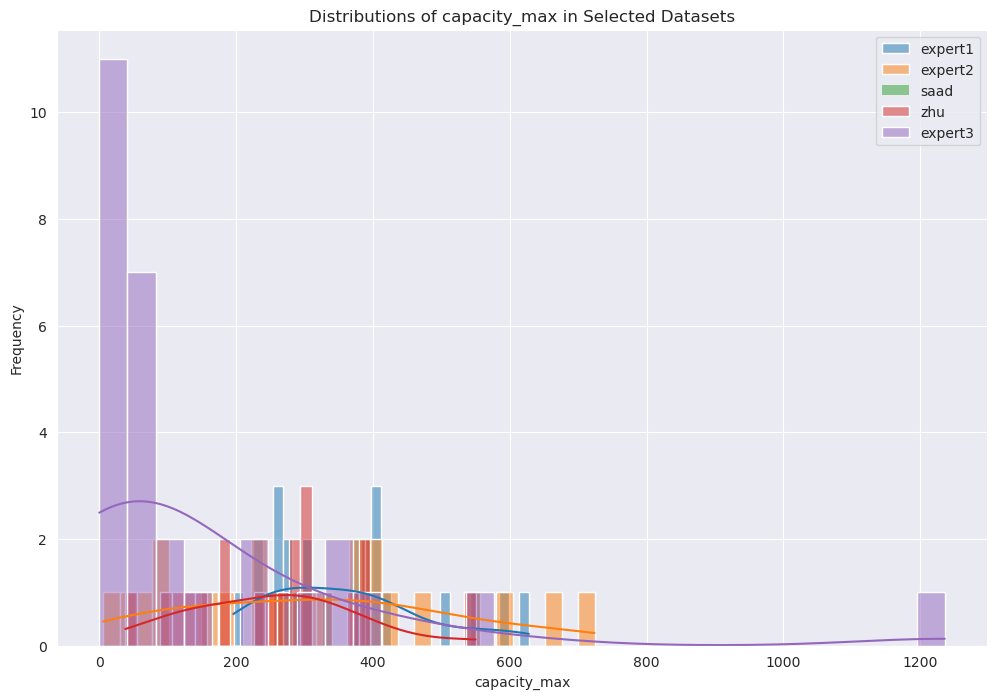

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Plot the distributions of capacity_max

plt.figure(figsize=(12, 8))
for name, df in dfs.items():
    print(name, df['capacity_max'].min(), df['capacity_max'].max())
    sns.histplot(df['capacity_max'], kde=True, label=name, bins=30)

plt.title('Distributions of capacity_max in Selected Datasets')
plt.xlabel('capacity_max')
plt.ylabel('Frequency')
plt.legend()
plt.show()

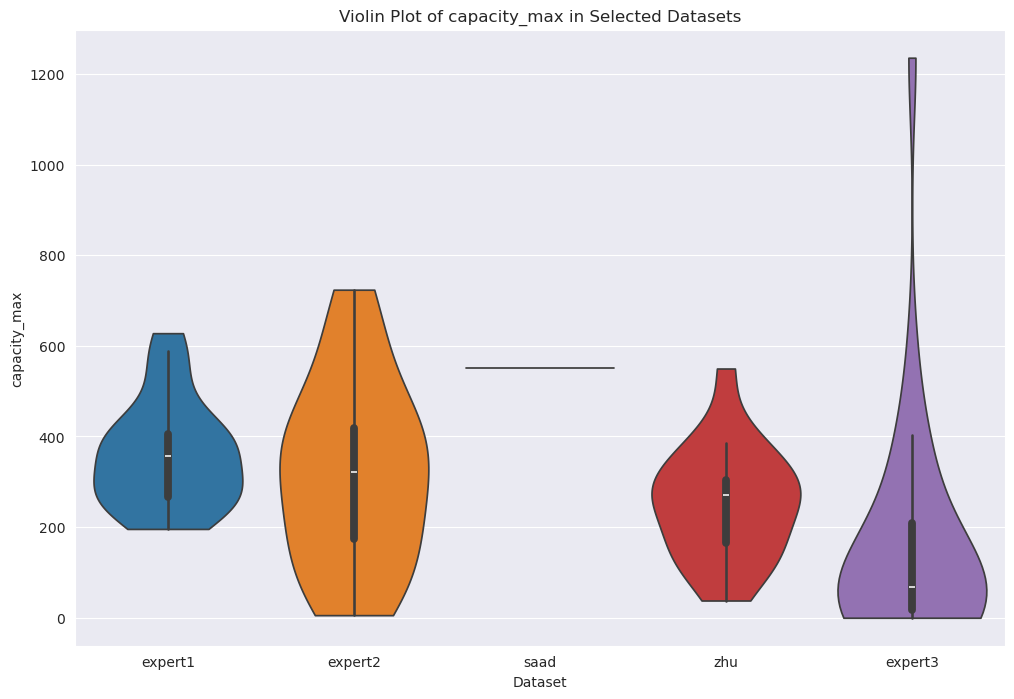

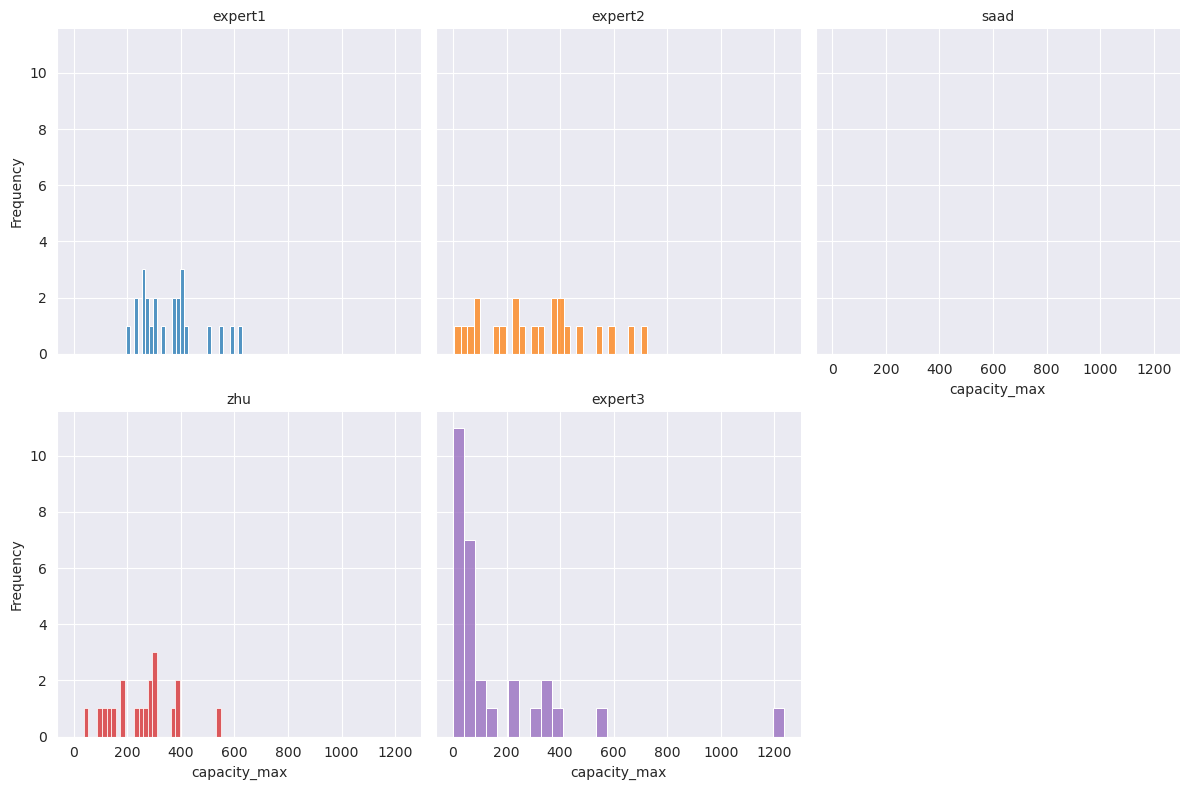

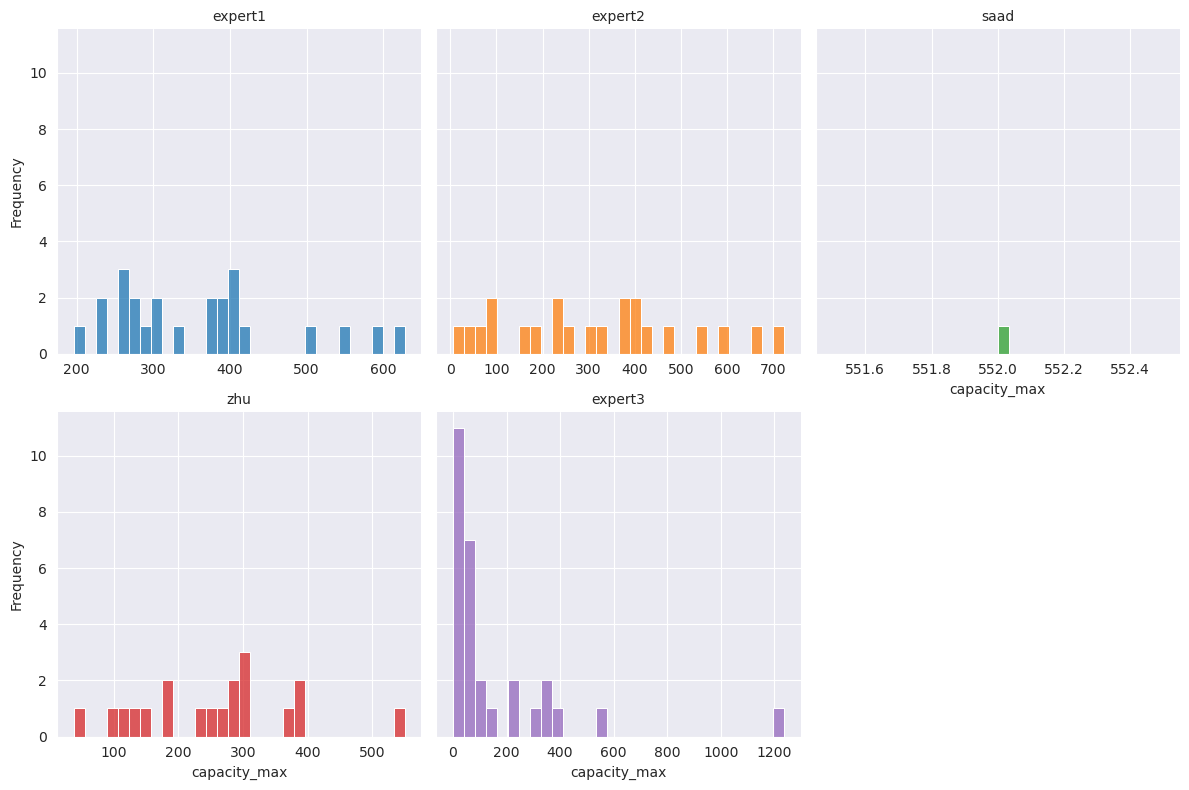

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Combine datasets into a single DataFrame for facet plot
df_combined = pd.concat([df.assign(dataset=name) for name, df in dfs.items()], ignore_index=True)

# Create a violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x='dataset', y='capacity_max', data=df_combined, cut=0, hue='dataset')
plt.title('Violin Plot of capacity_max in Selected Datasets')
plt.xlabel('Dataset')
plt.ylabel('capacity_max')
plt.show()

# Create a facet plot with each dataset on a separate plot
g = sns.FacetGrid(df_combined, col='dataset', col_wrap=3, height=4, sharex=True, sharey=True, hue='dataset')
g.map(sns.histplot, 'capacity_max', kde=False, bins=30)
g.set_titles(col_template="{col_name}")
g.set_axis_labels('capacity_max', 'Frequency')
plt.show()

# Create a facet plot with each dataset on a separate plot
g = sns.FacetGrid(df_combined, col='dataset', col_wrap=3, height=4, sharex=False, sharey=True, hue='dataset')
g.map(sns.histplot, 'capacity_max', kde=False, bins=30)
g.set_titles(col_template="{col_name}")
g.set_axis_labels('capacity_max', 'Frequency')
plt.show()

In [3]:
df = pd.concat(dfs, ignore_index=True)
df

,smiles,capacity_max,flatness,ps,%c,%n,%o,mollogp,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt,symmetry
0,C#Cc1ccc(C#N)cc1,628.0,0.158494,1.527471,90.000000,10.000000,0.000000,1.53958,10,10,1,1,0,1,0,23.79,127.042199,C2v
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,1.750266,3.422303,90.476190,9.523810,0.000000,9.74536,42,47,6,4,6,4,0,57.44,544.262697,C1
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,269.0,1.674914,3.444589,81.818182,13.636364,0.000000,9.33480,44,51,8,8,4,6,0,83.22,602.134737,C1
3,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4cccc...,228.0,0.732465,2.853515,84.375000,9.375000,0.000000,7.84640,32,36,5,5,4,3,0,38.67,453.079953,C1
4,Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1,196.0,0.690551,2.203633,65.000000,25.000000,0.000000,2.51710,20,22,3,7,2,5,0,55.44,304.015127,C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,O=S1(=O)c2ccc(Br)cc2S(=O)(=O)c2cc(-c3ccc(-c4cc...,52.0,1.708517,4.678455,81.481481,0.000000,7.407407,13.01360,54,61,7,10,7,4,0,68.28,999.816250,C1
91,OB(O)c1cc(B(O)O)c2ccc3c(B(O)O)cc(-c4ccc5c(c4)c...,75.3,2.013054,5.058348,75.757576,6.060606,9.090909,7.89110,66,78,12,16,4,10,6,172.94,1049.983812,C1
92,OB(O)c1ccc(-c2cc(-c3ccc(-c4ccc5c(c4)c4cc(Br)cc...,24.9,1.987410,5.789660,80.281690,7.042254,5.633803,12.20230,71,83,13,14,6,9,4,145.37,1109.019052,C1
93,OB(O)c1ccc(-c2nc(-c3ccc(B(O)O)cc3)nc(-c3ccc(-c...,121.9,1.497801,5.874983,77.464789,9.859155,5.633803,10.99230,71,83,13,16,6,11,4,171.15,1111.009550,C1


In [4]:
num_bins = 6
bins = pd.qcut(df['capacity_max'], q=num_bins, labels=None)
bins

0     (406.333, 1236.0]
1        (169.0, 256.0]
2        (256.0, 335.0]
3        (169.0, 256.0]
4        (169.0, 256.0]
            ...        
90      (51.767, 169.0]
91      (51.767, 169.0]
92     (-0.001, 51.767]
93      (51.767, 169.0]
94      (51.767, 169.0]
Name: capacity_max, Length: 95, dtype: category
Categories (6, interval[float64, right]): [(-0.001, 51.767] < (51.767, 169.0] < (169.0, 256.0] < (256.0, 335.0] < (335.0, 406.333] < (406.333, 1236.0]]

In [5]:
num_bins = 6
bins = pd.cut(df['capacity_max'], bins=num_bins, labels=False)
bins

0     3
1     1
2     1
3     1
4     0
     ..
90    0
91    0
92    0
93    0
94    0
Name: capacity_max, Length: 95, dtype: int64

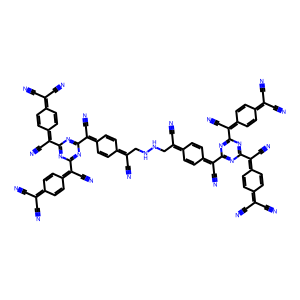

In [26]:
from rdkit import Chem
from rdkit.Chem import AllChem

# Define the reaction SMARTS
# This reaction connects two nitrile groups via their nitrogen atoms
reaction_smarts = '[C:1]#[N:2].[C:3]#[N:4]>>[C:1]-[N:2]-[N:4]-[C:3]'
reaction = AllChem.ReactionFromSmarts(reaction_smarts)

# Define the reactant molecules with nitrile groups
mol1 = Chem.MolFromSmiles('N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#N)C#N)cc1)nc(C(C#N)=c2ccc(=C(C#N)C#N)cc2)n3)cc4')  # Acetonitrile
mol2 = Chem.MolFromSmiles('N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#N)C#N)cc1)nc(C(C#N)=c2ccc(=C(C#N)C#N)cc2)n3)cc4')  # Propionitrile

# Run the reaction
products = reaction.RunReactants((mol1, mol2))

for _ in range(0):
    product = products[0][0]
    Chem.SanitizeMol(product)
    products = reaction.RunReactants((product, mol1))
product = products[0][0]
display(Chem.Draw.MolToImage(product))

# # Iterate over possible products and display their SMILES
# for product_set in products:
#     for product in product_set:
#         Chem.SanitizeMol(product)
#         print(Chem.MolToSmiles(product))
#         display(Chem.Draw.MolToImage(product))

expert1_corrected
0 CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(-c4nc(-c5ccc(-c6cc7c(cc(-c8ccc(C#N)cc8)n7-c7ccc(C(C)C)cc7)n6-c6ccc(C(C)C)cc6)cc5)nc(-c5ccc(-c6cc7c(cc(-c8ccc(C#N)cc8)n7-c7ccc(C(C)C)cc7)n6-c6ccc(C(C)C)cc6)cc5)n4)cc2)n3-c2ccc(C(C)C)cc2)cc1


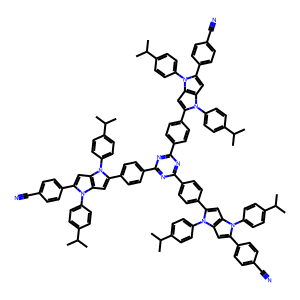

1 N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc3)n2)cc1


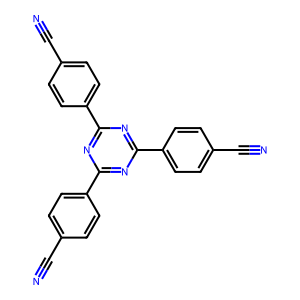

2 N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#N)C#N)cc3)nc(C(C#N)=c3ccc(=C(C#N)C#N)cc3)n2)cc1


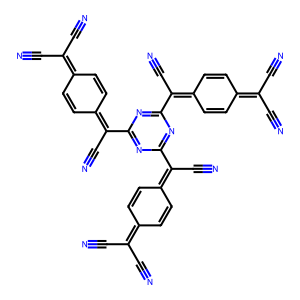

3 Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-c5nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8nc9ccc(C)cc9s8)n7-c7nc8ccc(C)cc8s7)cc6)nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8nc9ccc(C)cc9s8)n7-c7nc8ccc(C)cc8s7)cc6)n5)cc3)n4-c3nc4ccc(C)cc4s3)sc2c1


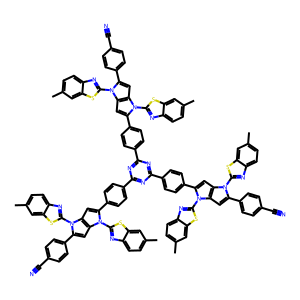

4 N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8ccc(C#N)cc8)n7-c7ccc(C#N)cc7)cc6)nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8ccc(C#N)cc8)n7-c7ccc(C#N)cc7)cc6)n5)cc4)n3-c3ccc(C#N)cc3)n2-c2ccc(C#N)cc2)cc1


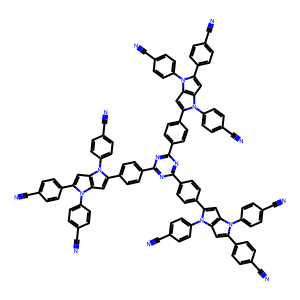

5 Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(Cl)n5)cc4)cc(-c4ccc(-c5nc(Cl)nc(Cl)n5)cc4)c3)cc2)n1


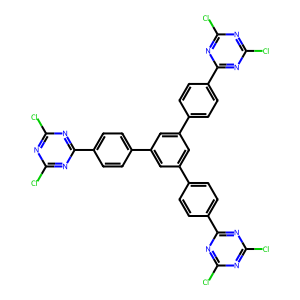

6 N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(-c6nc(-c7ccc(-n8c(=O)c9cc%10c(=O)n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)nc(-c7ccc(-n8c(=O)c9cc%10c(=O)n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)n6)cc5)c(=O)c4cc3c2=O)cc1


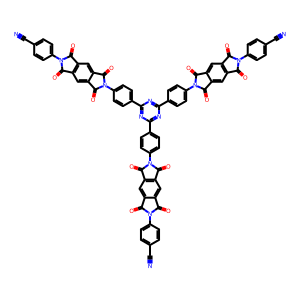

7 N#Cc1cncc(-c2nc(-c3cncc(C#N)c3)nc(-c3cncc(C#N)c3)n2)c1


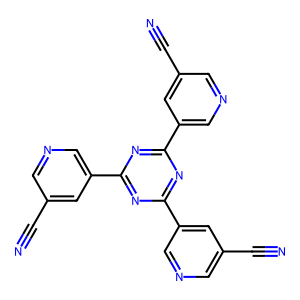

8 Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)c4ccc(N)cc4C5=O)nc(Nc4ccc5c(c4)C(=O)c4ccc(N)cc4C5=O)n3)cc1C2=O


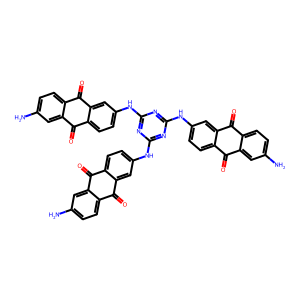

9 c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)nc(-[n+]4ccc(-c5ccncc5)cc4)n3)cc2)ccn1


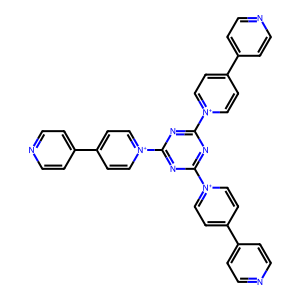

10 N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1


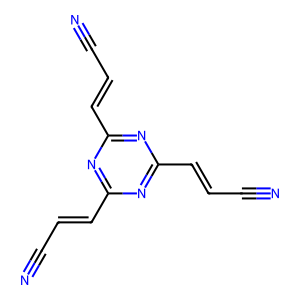

11 Nc1cc(O)c(N=Cc2ccc(-c3nc(-c4ccc(/C=N\c5cc(O)c(N)cc5O)cc4)nc(-c4ccc(/C=N/c5cc(O)c(N)cc5O)cc4)n3)cc2)cc1O


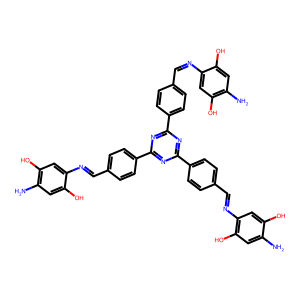

12 N#Cc1ccc(-n2[nH]c(=O)c3cc4c(=O)[nH]n(-c5ccc(-c6nc(-c7ccc(-n8[nH]c(=O)c9cc%10c(=O)[nH]n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)nc(-c7ccc(-n8[nH]c(=O)c9cc%10c(=O)[nH]n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)n6)cc5)c(=O)c4cc3c2=O)cc1


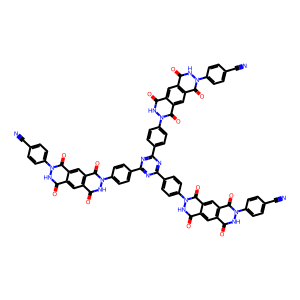

13 N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc4)nc(-c4ccc(-c5ccc(C#N)cc5)cc4)n3)cc2)cc1


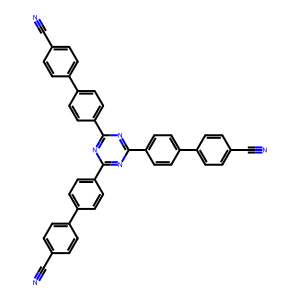

14 N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cn5)nc4)nc(-c4ccc(-c5ccc(C#N)cn5)nc4)n3)cn2)nc1


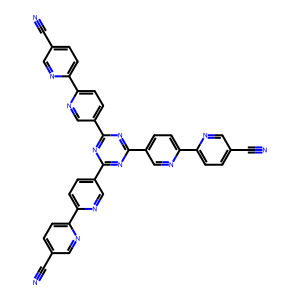

15 N#Cc1cccc(-c2nc(-c3cccc(C#N)n3)nc(-c3cccc(C#N)n3)n2)n1


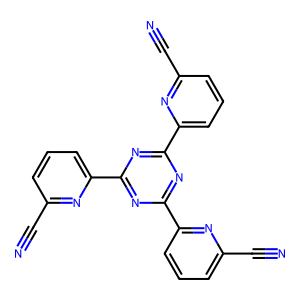

16 N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)nc(-c3c(F)c(F)c(C#N)c(F)c3F)n2)c(F)c1F


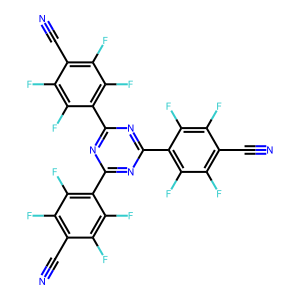

17 O=CN1CCN(C=Nc2nc(/N=C/N3CCN(C=O)CC3)nc(/N=C/N3CCN(C=O)CC3)n2)CC1


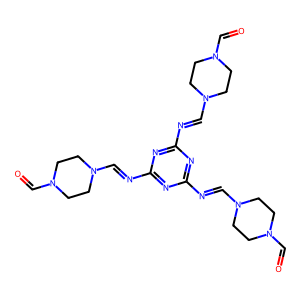

18 O=c1oc(=O)c2cc3c(=O)n(-c4ccc(-c5nc(-c6ccc(-n7c(=O)c8cc9c(=O)oc(=O)c9cc8c7=O)cc6)nc(-c6ccc(-n7c(=O)c8cc9c(=O)oc(=O)c9cc8c7=O)cc6)n5)cc4)c(=O)c3cc12


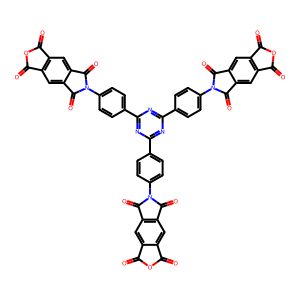

19 O=C1OC(=O)c2ccc3c4c(ccc1c24)C(=O)N(c1ccc(-c2nc(-c4ccc(N5C(=O)c6ccc7c8c(ccc(c68)C5=O)C(=O)OC7=O)cc4)nc(-c4ccc(N5C(=O)c6ccc7c8c(ccc(c68)C5=O)C(=O)OC7=O)cc4)n2)cc1)C3=O


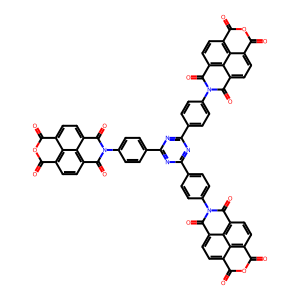

20 Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4cc(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4)nc3)n2)cn1


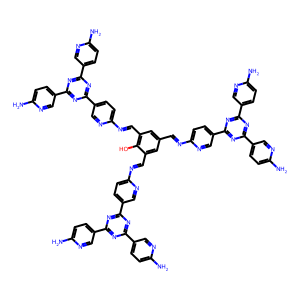

21 Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4cc(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4O)nc3)n2)cn1


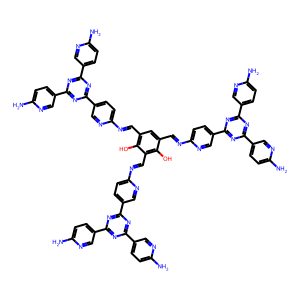

22 Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4O)nc3)n2)cn1


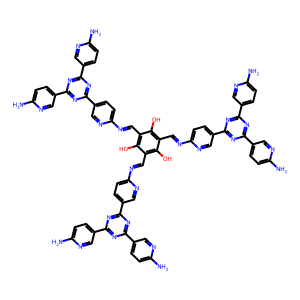

23 N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc34)nc(-c3c4ccccc4c(C#N)c4ccccc34)n2)c2ccccc12


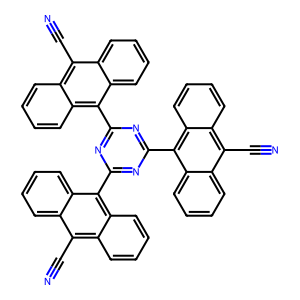

24 C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc3)n2)cc1


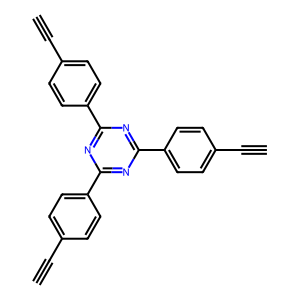

25 N#Cc1cc(C#N)c2ccc3cc(-c4nc(-c5cc6ccc7c(C#N)cc(C#N)c8ccc(c5)c6c78)nc(-c5cc(C#N)c6ccc7c(C#N)cc(C#N)c8ccc5c6c78)n4)cc4ccc1c2c43


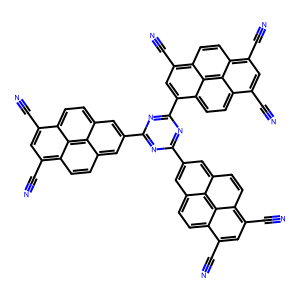

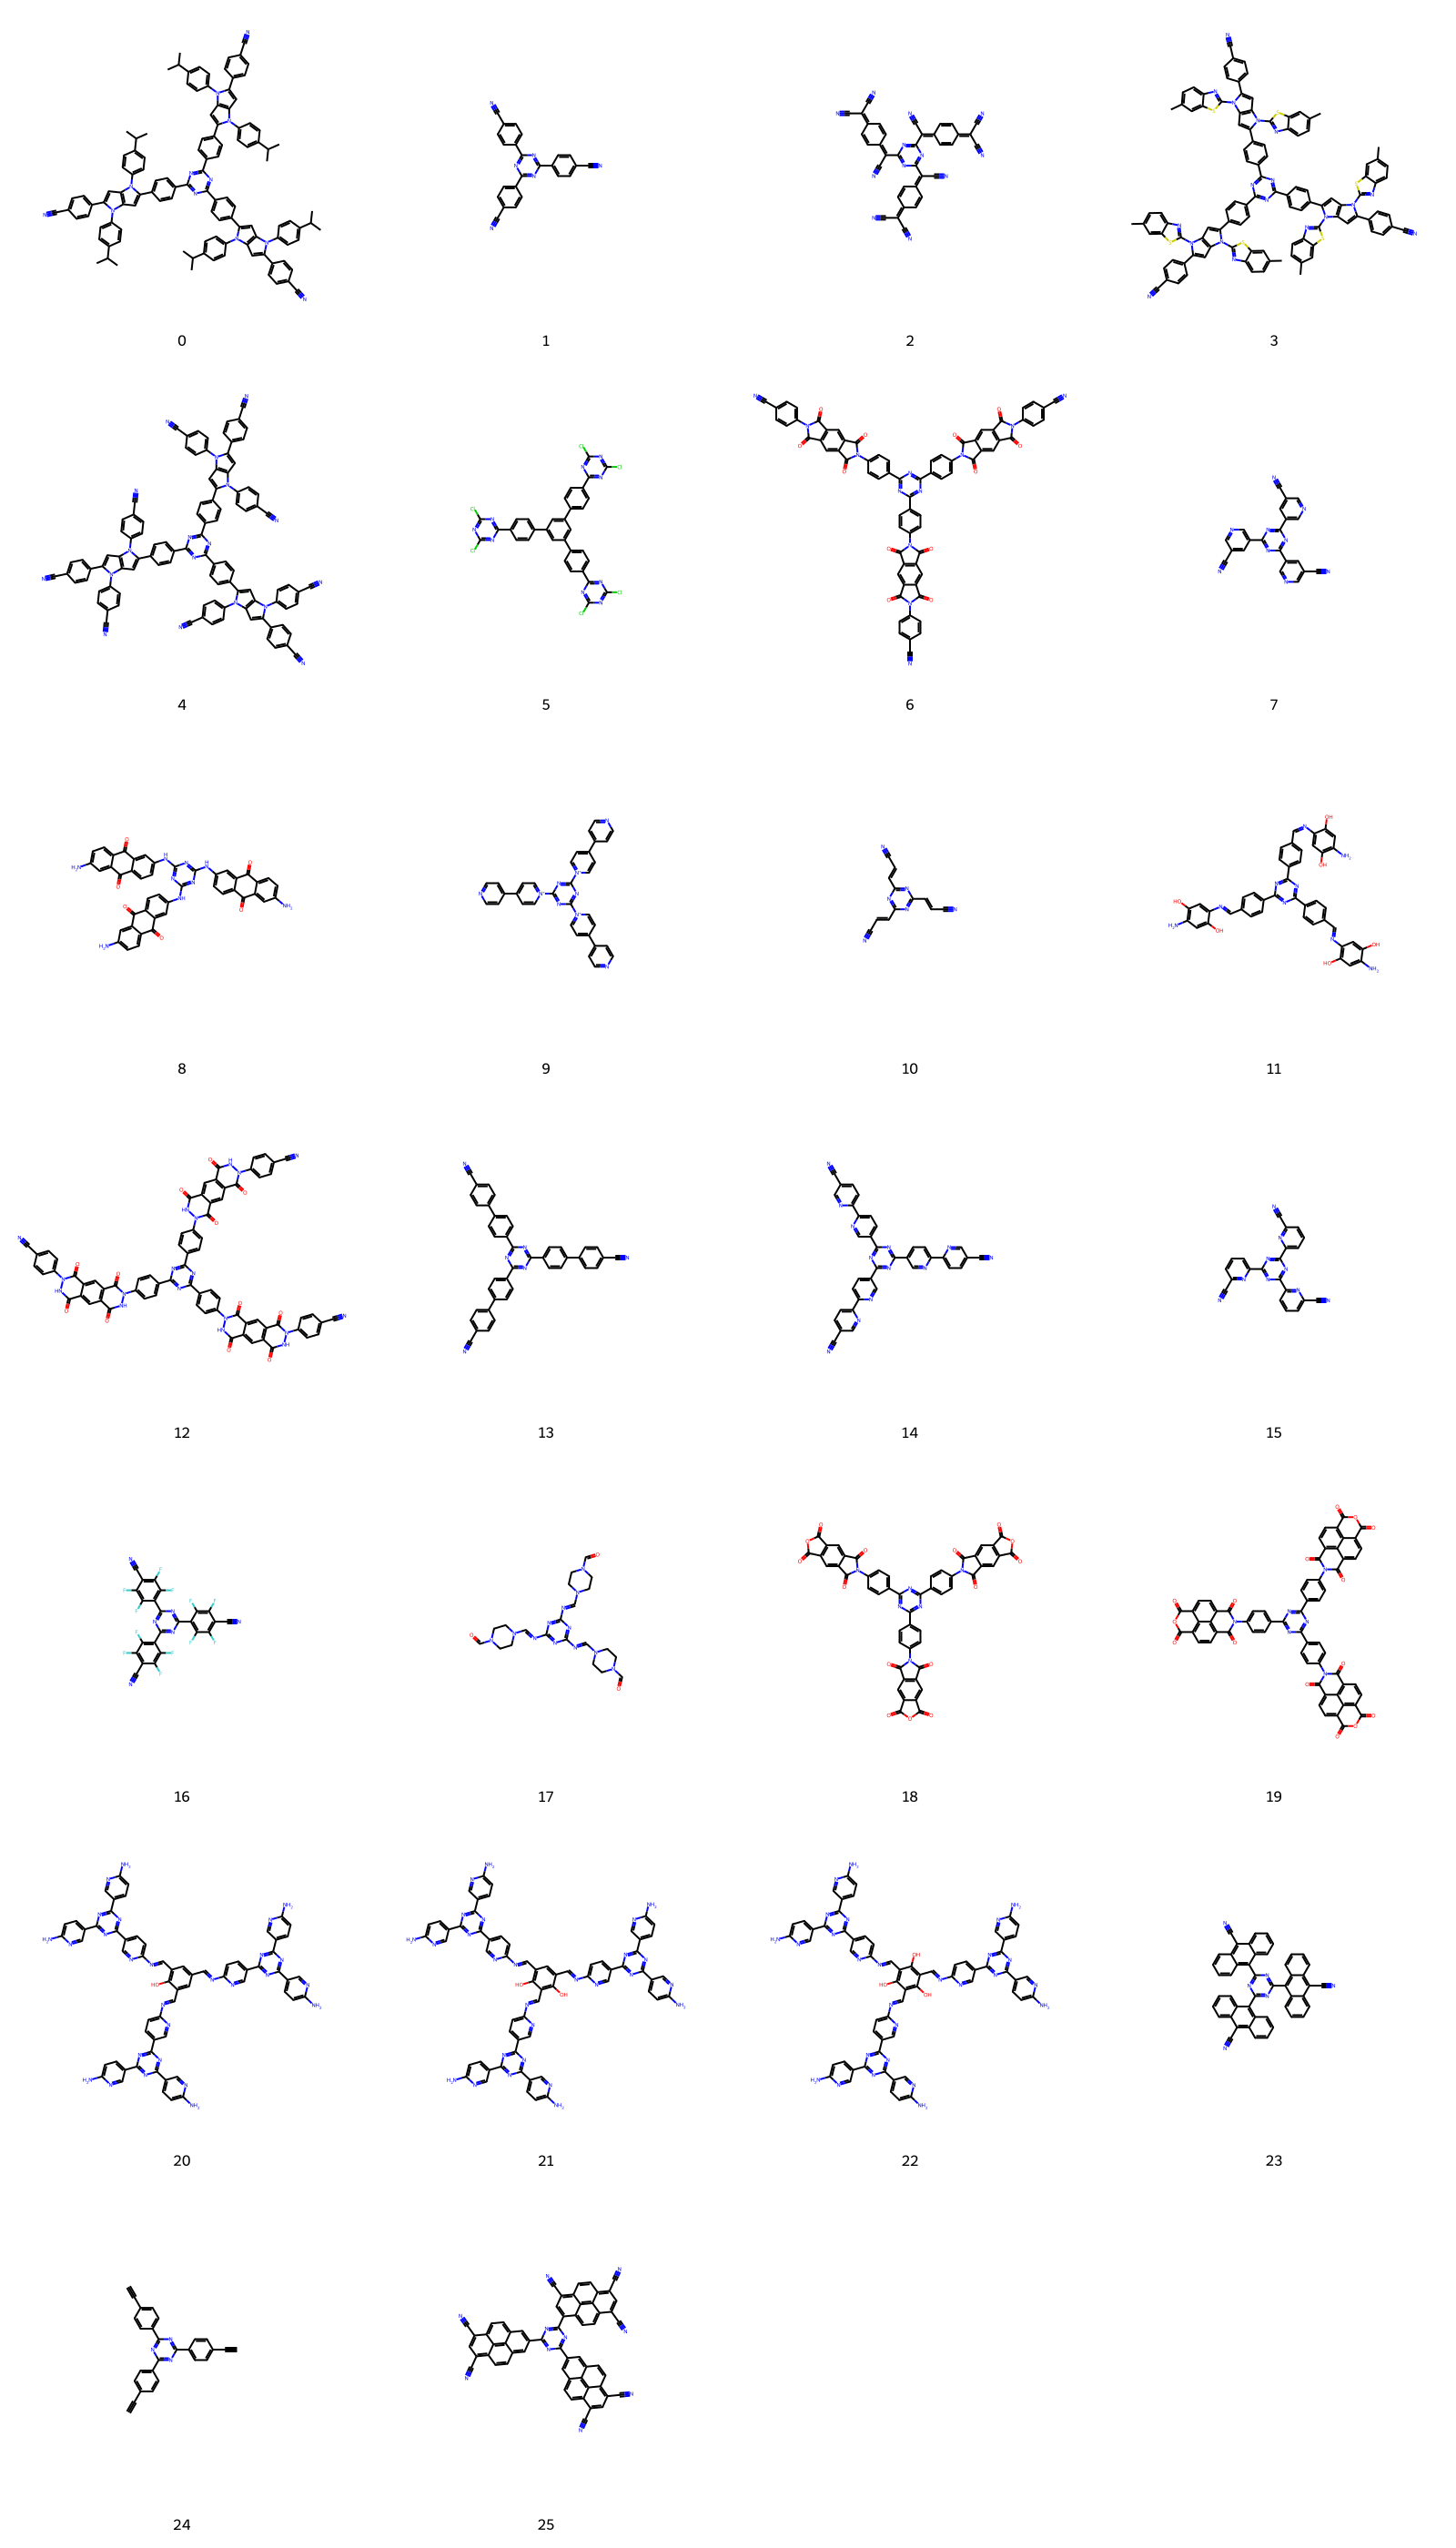

--------------------------------------------


In [3]:
import numpy as np
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit import Chem
import pandas as pd
from modules.core.features.utils import canon_smiles


data_paths = {
    # 'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert1_corrected': '../../../data/raw/data_experts1_corrected.csv',
    # 'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    # 'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    # 'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    # 'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}
for data_name, df_path in data_paths.items():
    df_small = pd.read_csv(df_path)
    print(data_name)

    if data_name == 'expert1_corrected':
        smiles = df_small['smiles'].drop_duplicates().tolist()
    else:
        smiles = df_small['smiles'].drop_duplicates().tolist()
    smiles = [canon_smiles(s) for s in smiles]
    df = pd.DataFrame({'smiles': smiles})
    PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
    df['id'] = list(range(len(df)))
    for i, s in enumerate(smiles):
        print(i, s)
        mol = Chem.MolFromSmiles(s)
        display(Draw.MolToImage(mol))
    #mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    #display(Draw.MolsToGridImage(mols, molsPerRow=4))
    display(PandasTools.FrameToGridImage(df, legendsCol="id", molsPerRow=4, subImgSize=(400, 400)))
    print('--------------------------------------------')

0 0.0 196.0 36


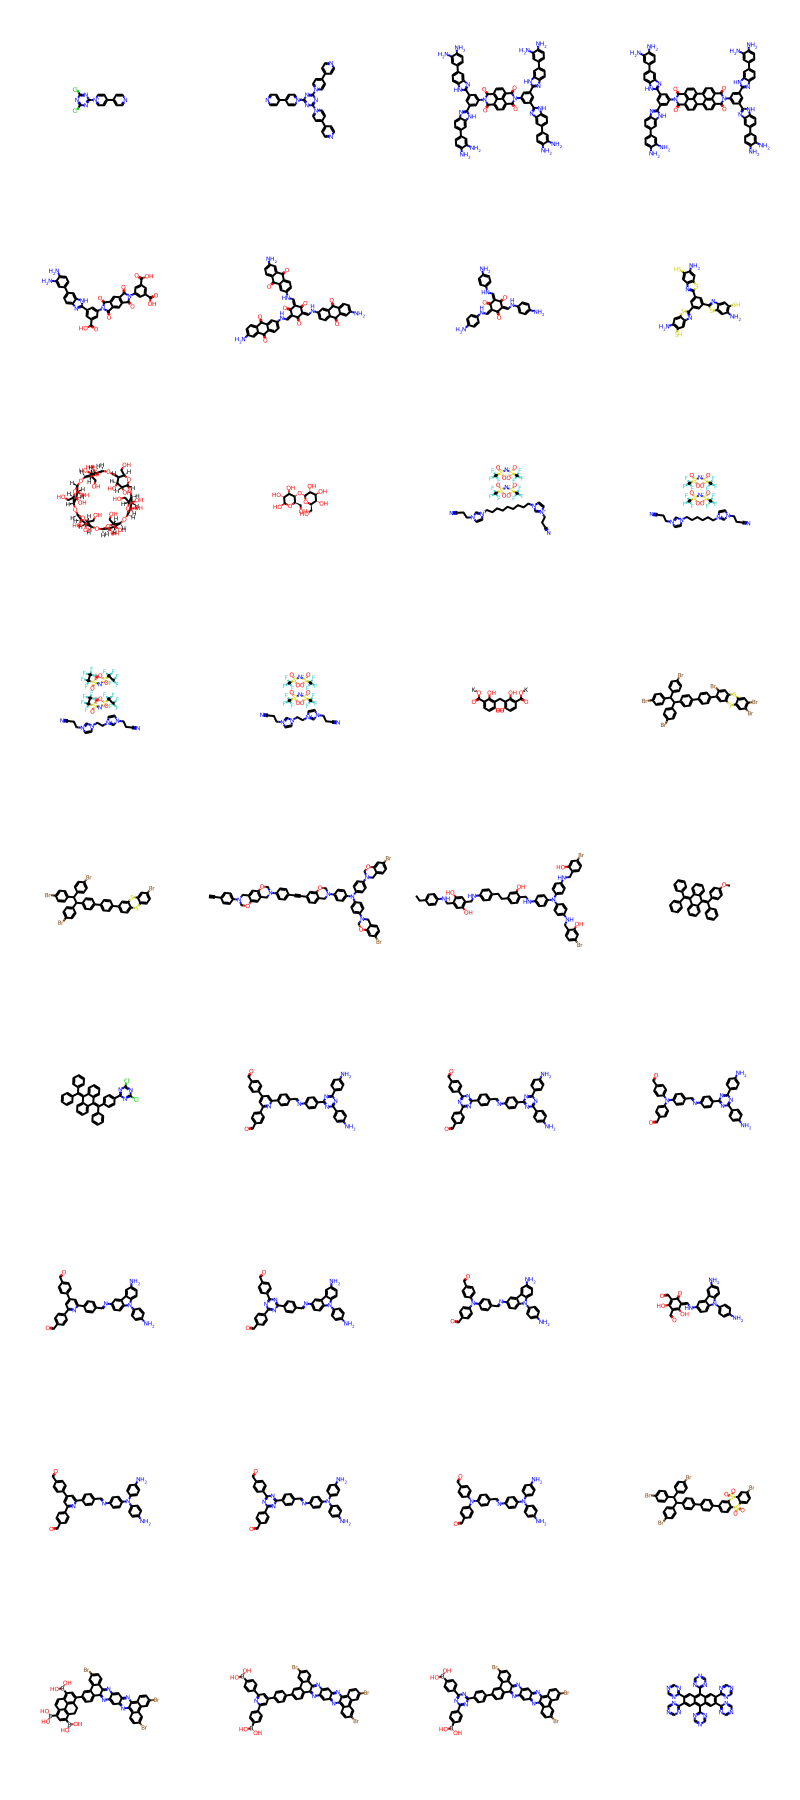

1 209.0 407.0 44


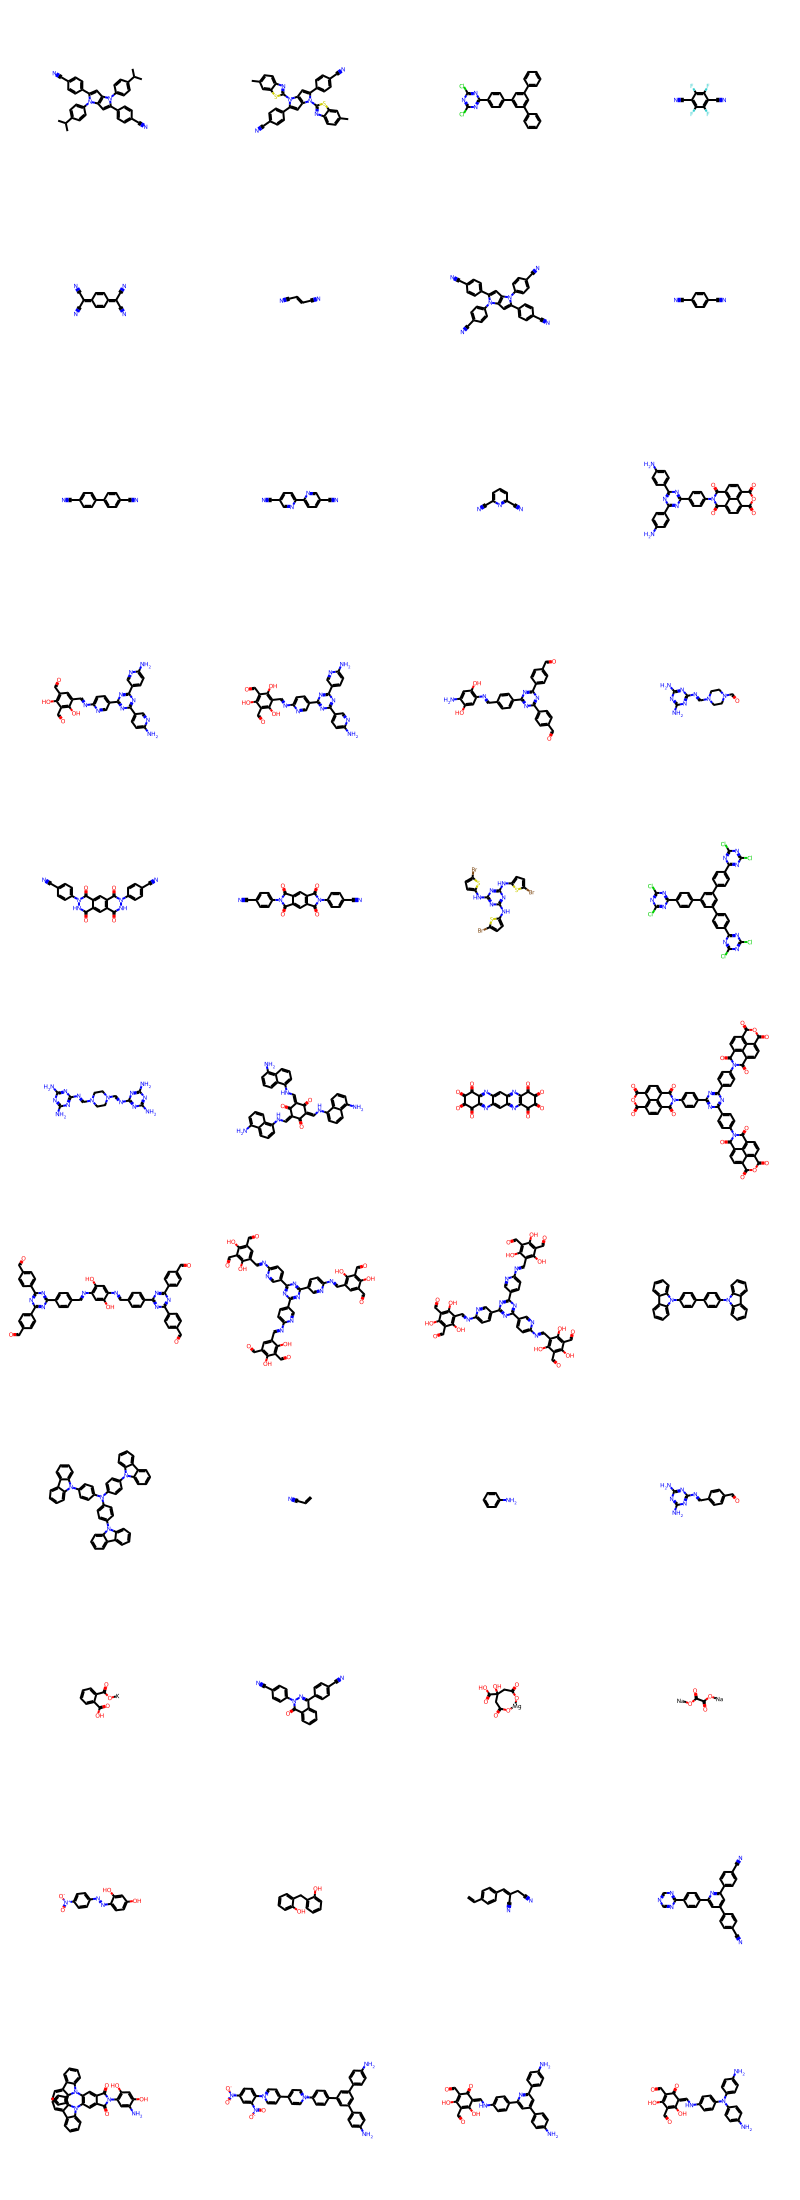

2 423.0 589.0 11


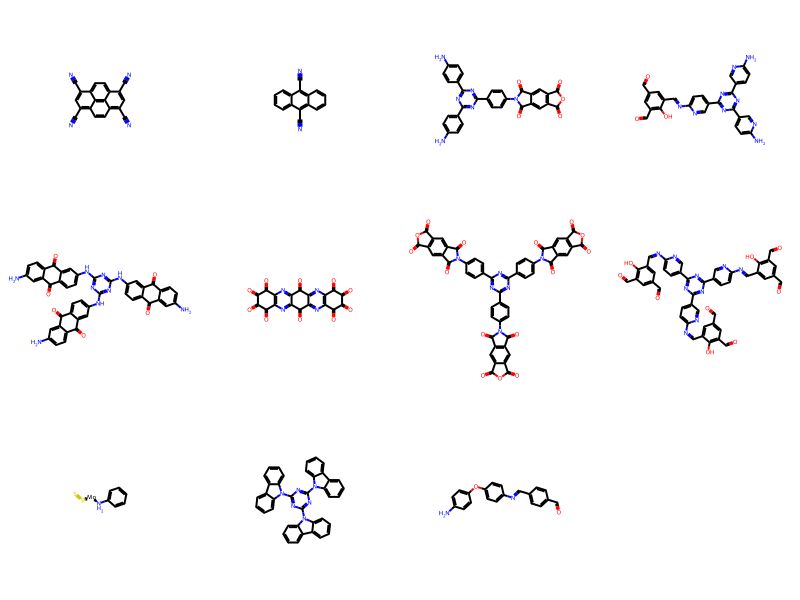

3 628.0 724.0 3


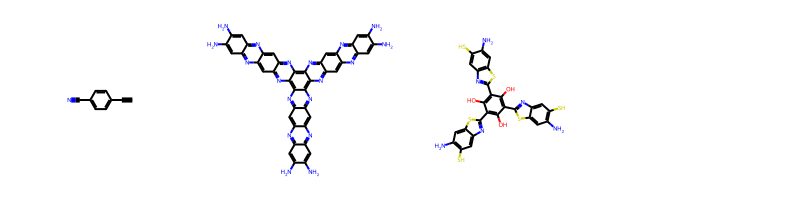

5 1236.0 1236.0 1


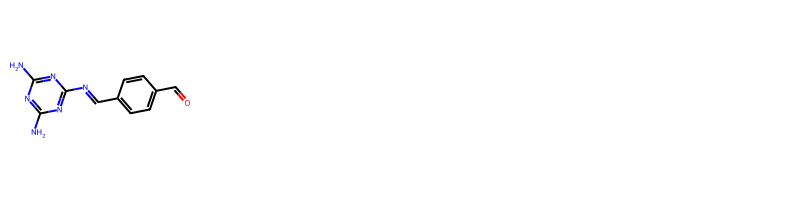

In [6]:
import numpy as np
from rdkit.Chem import Draw
from rdkit import Chem

df['bins'] = bins
unique_bins = sorted(np.unique(bins.tolist()))
for b in unique_bins:
    df_small = df[df['bins'] == b]
    print(b, df_small['capacity_max'].min(), df_small['capacity_max'].max(), len(df_small))
    smiles = df_small['smiles'].tolist()
    mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    display(Draw.MolsToGridImage(mols, molsPerRow=4))
    plt.show()

In [10]:
#point-biserial

import pandas as pd
import numpy as np
from scipy import stats

custom_features = '../../../data/processed_selected_custom_features/data_experts1.csv'
maccs_features = '../../../data/fingerprints_maccs/data_experts1.csv'
df_custom = pd.read_csv(custom_features)
df_custom.sort_values(by='smiles', inplace=True)
df_custom = df_custom[['flatness', 'ps']]
df_maccs = pd.read_csv(maccs_features)
df_maccs.sort_values(by='smiles', inplace=True)
df_maccs.drop(columns=['capacity_max', 'smiles'], inplace=True)

correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.pointbiserialr(df_maccs[col2], df_custom[col1]).correlation

correlation_matrix.T


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/scipy/stats/_stats_py.py:5657: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,flatness,ps
maccsfingerprint0,NaN,NaN
maccsfingerprint1,NaN,NaN
maccsfingerprint2,NaN,NaN
maccsfingerprint3,NaN,NaN
maccsfingerprint4,NaN,NaN
...,...,...
maccsfingerprint161,0.277431,0.343533
maccsfingerprint162,0.277431,0.343533
maccsfingerprint163,0.420592,0.667015
maccsfingerprint164,0.277431,0.343533


In [19]:
import pandas as pd
import numpy as np
from scipy import stats
data_names = ['experts1', 'experts2', ]#'experts3', 'saad', 'zhu']
custom_features = [f'../../../data/processed_selected_custom_features/data_{dname}.csv' for dname in data_names]
maccs_features = [f'../../../data/fingerprints_maccs/data_{dname}.csv' for dname in data_names]
df_custom = pd.concat([pd.read_csv(cf) for cf in custom_features], ignore_index=True)
df_custom.sort_values(by='smiles', inplace=True)
df_custom = df_custom[['flatness', 'ps']]
df_maccs = pd.concat([pd.read_csv(cf) for cf in maccs_features], ignore_index=True)
df_maccs.sort_values(by='smiles', inplace=True)
df_maccs.drop(columns=['capacity_max', 'smiles'], inplace=True)
df_maccs.describe()
correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.pointbiserialr(df_maccs[col2], df_custom[col1]).correlation
#
correlation_matrix.T

/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/scipy/stats/_stats_py.py:5657: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,flatness,ps
maccsfingerprint0,NaN,NaN
maccsfingerprint1,NaN,NaN
maccsfingerprint2,NaN,NaN
maccsfingerprint3,NaN,NaN
maccsfingerprint4,NaN,NaN
...,...,...
maccsfingerprint161,0.171201,0.247477
maccsfingerprint162,0.171201,0.247477
maccsfingerprint163,0.42096,0.604048
maccsfingerprint164,0.171201,0.247477


In [20]:
correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.spearmanr(df_maccs[col2], df_custom[col1]).correlation
#
correlation_matrix.T

/tmp/ipykernel_4497/43190432.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation_matrix.iloc[i, j] = stats.spearmanr(df_maccs[col2], df_custom[col1]).correlation


,flatness,ps
maccsfingerprint0,NaN,NaN
maccsfingerprint1,NaN,NaN
maccsfingerprint2,NaN,NaN
maccsfingerprint3,NaN,NaN
maccsfingerprint4,NaN,NaN
...,...,...
maccsfingerprint161,0.196502,0.252646
maccsfingerprint162,0.196502,0.252646
maccsfingerprint163,0.422434,0.629542
maccsfingerprint164,0.196502,0.252646


In [16]:
f_to_remove = []
for i, col in enumerate(df_maccs.columns):
    if df_maccs[col].max() == df_maccs[col].min():
        f_to_remove.append(col)
f_to_remove

['maccsfingerprint0',
 'maccsfingerprint1',
 'maccsfingerprint2',
 'maccsfingerprint3',
 'maccsfingerprint4',
 'maccsfingerprint5',
 'maccsfingerprint7',
 'maccsfingerprint8',
 'maccsfingerprint10',
 'maccsfingerprint11',
 'maccsfingerprint12',
 'maccsfingerprint13',
 'maccsfingerprint14',
 'maccsfingerprint15',
 'maccsfingerprint18',
 'maccsfingerprint19',
 'maccsfingerprint20',
 'maccsfingerprint21',
 'maccsfingerprint22',
 'maccsfingerprint25',
 'maccsfingerprint26',
 'maccsfingerprint28',
 'maccsfingerprint29',
 'maccsfingerprint30',
 'maccsfingerprint36',
 'maccsfingerprint38',
 'maccsfingerprint39',
 'maccsfingerprint47',
 'maccsfingerprint67',
 'maccsfingerprint107',
 'maccsfingerprint114',
 'maccsfingerprint115']

In [18]:
new_dir = '../../../data/selected_maccs'
import os
os.makedirs(new_dir, exist_ok=True)
for data_name in data_names:
    print(data_name)
    df = pd.read_csv(f'../../../data/fingerprints_maccs/data_{data_name}.csv')
    print(df.head())
    df.drop(columns=f_to_remove, inplace=True)
    df.to_csv(f'{new_dir}/data_{data_name}.csv', index=False)

experts1
   maccsfingerprint0  maccsfingerprint1  maccsfingerprint2  maccsfingerprint3  \
0                  0                  0                  0                  0   
1                  0                  0                  0                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  0   

   maccsfingerprint4  maccsfingerprint5  maccsfingerprint6  maccsfingerprint7  \
0                  0                  0                  0                  0   
1                  0                  0                  0                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  0   

   maccsfingerpri